In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

# 1. 데이터 로드
df = pd.read_csv('../data/raw/machine_failure.csv')

# 2. 고장 데이터만 사용
df_failure = df[df['Machine failure'] == 1].copy()

rename_map = {
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rpm',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear'
}

df_failure = df_failure.rename(columns=rename_map)

print("고장 데이터 수:", len(df_failure))

# 3. 고장 유형 라벨 생성
def get_failure_type(row):
    if row['TWF'] == 1: return 0
    if row['HDF'] == 1: return 1
    if row['PWF'] == 1: return 2
    if row['OSF'] == 1: return 3
    if row['RNF'] == 1: return 4

df_failure = df_failure[
    df_failure[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) == 1
].copy()

df_failure['failure_type'] = df_failure.apply(get_failure_type, axis=1)

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

# 4. Feature 구성 (모델 1과 통일)
features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear'
]

# 파생 변수
df_failure['Temp_Diff'] = df_failure['process_temp'] - df_failure['air_temp']
df_failure['Power'] = df_failure['rpm'] * df_failure['torque']

features += ['Temp_Diff', 'Power']

X = df_failure[features]
y = df_failure['failure_type']

# 5. Train/Test 분리 (고장 유형 비율 유지!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. SMOTE (고장 유형 불균형 해결)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 7. 모델 정의 (다중분류)
model2 = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    class_weight='balanced',
    random_state=42
)

# 8. 학습
model2.fit(X_train_res, y_train_res)

# 9. 평가
y_pred = model2.predict(X_test)


input_data = {
    'air_temp': 305.0,
    'process_temp': 310.0,
    'rpm': 1450,
    'torque': 28.0,
    'tool_wear': 130
}

input_df = pd.DataFrame([input_data])

# 파생 변수 추가 (학습과 동일!)
input_df['temp_diff'] = input_df['process_temp'] - input_df['air_temp']
input_df['power'] = input_df['rpm'] * input_df['torque']

features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear',
    'temp_diff',
    'power'
]

X_input = input_df[features]

probs = model2.predict_proba(X_input)[0]

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

top2 = np.argsort(probs)[::-1][:2]

print("🔍 고장 원인 예측 Top-2")
for idx in top2:
    print(f"- {failure_map[idx]} 가능성: {probs[idx]*100:.1f}%")


고장 데이터 수: 339
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 622
[LightGBM] [Info] Number of data points in the train set: 340, number of used features: 7
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

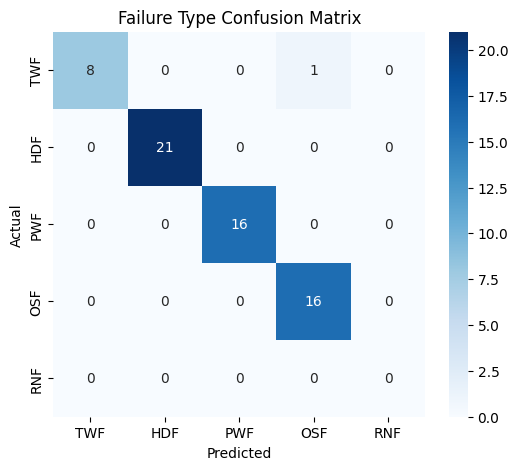

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['TWF','HDF','PWF','OSF','RNF'],
    yticklabels=['TWF','HDF','PWF','OSF','RNF'],
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Failure Type Confusion Matrix')
plt.show()

In [45]:
input_data = {
    'air_temp': 300.0,
    'process_temp': 310.0,
    'rpm': 850,
    'torque': 15.0,
    'tool_wear': 110
}

input_df = pd.DataFrame([input_data])

# 파생 변수 추가 (학습과 동일!)
input_df['temp_diff'] = input_df['process_temp'] - input_df['air_temp']
input_df['power'] = input_df['rpm'] * input_df['torque']

features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear',
    'temp_diff',
    'power'
]

X_input = input_df[features]

probs = model2.predict_proba(X_input)[0]

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

top2 = np.argsort(probs)[::-1][:2]

print("🔍 고장 원인 예측 Top-2")
for idx in top2:
    print(f"- {failure_map[idx]} 가능성: {probs[idx]*100:.1f}%")

🔍 고장 원인 예측 Top-2
- PWF 가능성: 94.5%
- TWF 가능성: 4.9%


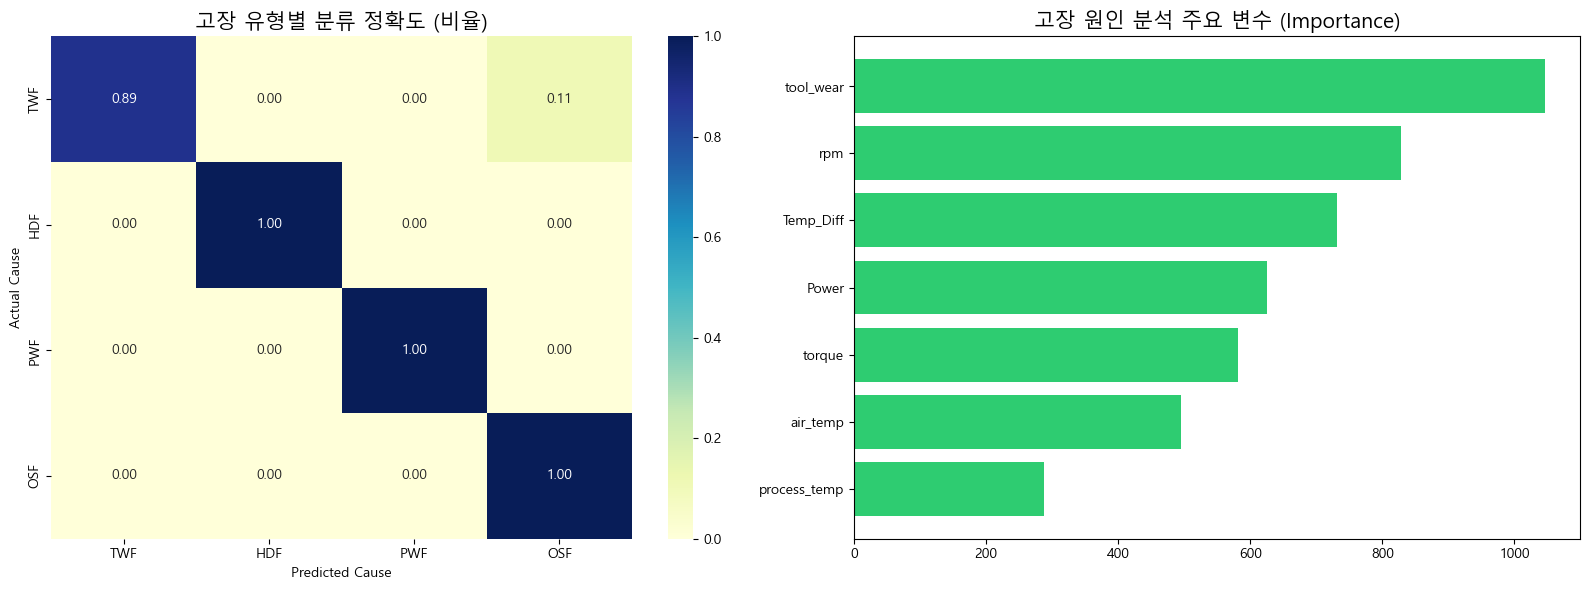


[고장 유형별 상세 분석 리포트]
              precision    recall  f1-score   support

         TWF       1.00      0.89      0.94         9
         HDF       1.00      1.00      1.00        21
         PWF       1.00      1.00      1.00        16
         OSF       0.94      1.00      0.97        16

    accuracy                           0.98        62
   macro avg       0.99      0.97      0.98        62
weighted avg       0.98      0.98      0.98        62



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def visualize_2nd_model(model, X_test, y_test, failure_map):
    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 예측값 생성
    y_pred = model.predict(X_test)
    
    # [수정 포인트] 현재 데이터에 실제로 존재하는 클래스들만 추출
    unique_labels = np.unique(np.concatenate([y_test, y_pred]))
    labels_names = [failure_map[i] for i in unique_labels]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # --- [그래프 1] Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    # 비율로 표시 (0으로 나누기 방지)
    cm_sum = cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.divide(cm.astype('float'), cm_sum, out=np.zeros_like(cm.astype('float')), where=cm_sum!=0)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax[0],
                xticklabels=labels_names, yticklabels=labels_names)
    ax[0].set_title('고장 유형별 분류 정확도 (비율)', fontsize=15)
    ax[0].set_xlabel('Predicted Cause')
    ax[0].set_ylabel('Actual Cause')

    # --- [그래프 2] Feature Importance ---
    # LightGBM의 경우 feature_importances_ 속성 사용
    importances = model.feature_importances_
    indices = np.argsort(importances)
    feature_names = X_test.columns
    
    ax[1].barh(range(len(indices)), importances[indices], color='#2ecc71', align='center')
    ax[1].set_yticks(range(len(indices)))
    ax[1].set_yticklabels([feature_names[i] for i in indices])
    ax[1].set_title('고장 원인 분석 주요 변수 (Importance)', fontsize=15)
    
    plt.tight_layout()
    plt.show()

    # 상세 리포트 출력 (존재하는 라벨만 적용)
    print("\n[고장 유형별 상세 분석 리포트]")
    print(classification_report(y_test, y_pred, labels=unique_labels, target_names=labels_names))

# 실행
visualize_2nd_model(model2, X_test, y_test, failure_map)